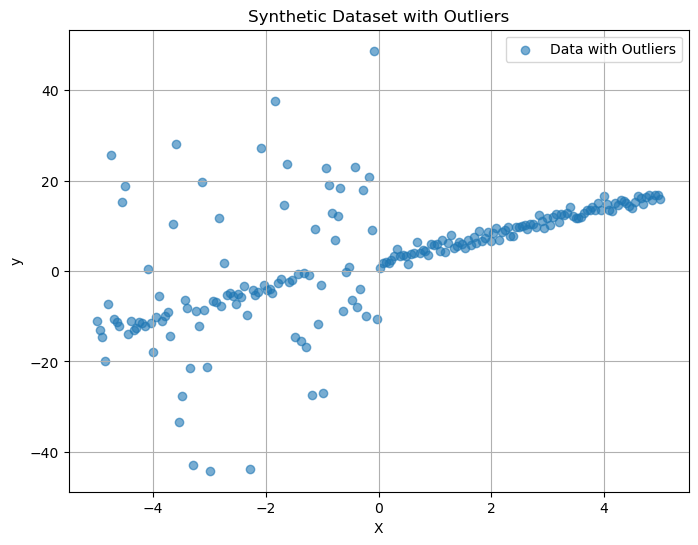

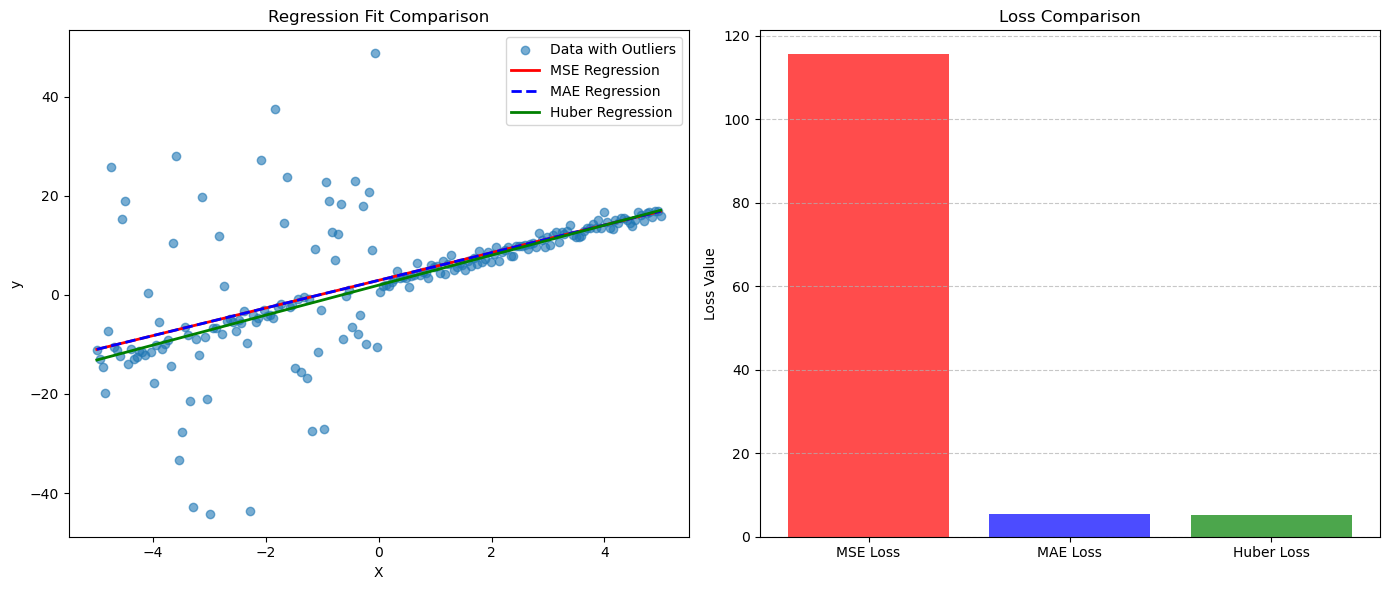

MSE Loss: 115.50268113225113
MAE Loss: 5.481830793241495
Huber Loss: 5.254215998129179


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Generate synthetic dataset with clearer MSE differences
np.random.seed(42)
X = np.linspace(-5, 5, 200).reshape(-1, 1)
y_true = 3 * X.ravel() + 2

# Introduce more severe outliers, grouped on one side
y = y_true + np.random.normal(0, 1, size=X.shape[0])
outlier_indices = np.random.choice(len(y) // 2, size=60, replace=False)  # Grouped on one side
y[outlier_indices] += np.random.normal(0, 20, size=60)  # Change size to 60

# Plot the dataset before training
plt.figure(figsize=(8, 6))
plt.scatter(X, y, label="Data with Outliers", alpha=0.6)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Dataset with Outliers")
plt.legend()
plt.grid()
plt.show()

# Train models using sklearn
mse_model = LinearRegression()
mse_model.fit(X, y)
mae_model = LinearRegression()
mae_model.fit(X, y)
huber_model = HuberRegressor()
huber_model.fit(X, y)

# Predictions
y_pred_mse = mse_model.predict(X)
y_pred_mae = mae_model.predict(X)
y_pred_huber = huber_model.predict(X)

# Compute losses
mse_loss = mean_squared_error(y, y_pred_mse)
mae_loss = mean_absolute_error(y, y_pred_mae)
huber_loss = mean_absolute_error(y, y_pred_huber)

# Plot fitted regression lines and loss comparison
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Regression Fit Plot
ax[0].scatter(X, y, label="Data with Outliers", alpha=0.6)
ax[0].plot(X, y_pred_mse, label="MSE Regression", color='r', linewidth=2)
ax[0].plot(X, y_pred_mae, label="MAE Regression", color='b', linewidth=2, linestyle='dashed')
ax[0].plot(X, y_pred_huber, label="Huber Regression", color='g', linewidth=2)  # Solid line for Huber
ax[0].set_xlabel("X")
ax[0].set_ylabel("y")
ax[0].set_title("Regression Fit Comparison")
ax[0].legend()

# Loss Comparison Bar Chart
loss_values = [mse_loss, mae_loss, huber_loss]
loss_labels = ["MSE Loss", "MAE Loss", "Huber Loss"]
ax[1].bar(loss_labels, loss_values, color=['r', 'b', 'g'], alpha=0.7)
ax[1].set_title("Loss Comparison")
ax[1].set_ylabel("Loss Value")
ax[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Print losses
print(f"MSE Loss: {mse_loss}")
print(f"MAE Loss: {mae_loss}")
print(f"Huber Loss: {huber_loss}")
